# Dark Uncertainty: Chapter 10 Demo

**A two-agent newsvendor simulation showing operational cost leakage from a meaning shift not represented in Powell's Chapter 10 example as specified.**

---

### The premise

Every formal framework has a scope. The problem framework's scope is the set of named state variables and their dynamics. Chapter 10 does not include a state variable or diagnostic for what we call *dark uncertainty:* contextual drift in what a variable refers to, which is not observable from within the model's named state.

The *referents* of those variables — what each name points to operationally in the world — are not explicitly represented in the model. This notebook is a worked example of one referent shift occurring at that boundary.

The two-agent newsvendor model is correct. Inside its own scope it converges, tunes, and balances overage against underage exactly as described. There is no disagreement with the mathematics.

The claim made here concerns the boundary where the model meets an organization, highlighting the difference between "decisions about decisions" in a closed-book example model and the dynamic organizational networks in which real decision systems operate.

Organizations are fluid. Vendors get replaced. Definitions migrate when teams reorganize. Schemas drift when the original modeler retires. An LLM agent appears two years later and integrates a new upstream API because the inputs *appear* compatible. These conditions are not represented in the Chapter 10 state specification itself, because the model's variables describe quantities, not the operational meaning attached to those quantities.

This notebook runs the Chapter 10 model exactly as written, then introduces one realistic operational event: an upstream forecast vendor is silently replaced. The new vendor's output has the same units, the same range, and approximately the same statistical distribution.

The variable name in the schema does not change. What changes is what the number *means*, simulating a more realistic organizational environment in which decision systems operate:

- **Employees change:** The person who originally created the model leaves, and the rationale behind assumptions may disappear with them.

- **Data sources change:** Data ingestion pipelines evolve over time, while API endpoints and field names remain stable, creating opportunities for semantic drift.

- **Upstream/downstream feedback loops:** Decisions produced by one model may later appear as inputs into other systems.

- **Long-term contextual drift:** Definitions that appear stable locally may gradually diverge as organizations, language, incentives, and operating conditions evolve.

Concretely: the old vendor forecast *trailers needed at this facility next week*. The new vendor forecasts *trailers needed across the region next week, averaged across facilities*. Same API field name. Same realistic-looking number. But the new value no longer tracks this facility's specific week-to-week variation — it tracks a regional aggregate that overlaps only statistically on average. The field manager's policy still treats the number as a forecast of local demand because the model has no explicit representation of the referent shift.

The model continues operating. The bias smoothers stay near zero on average. The per-week costs resemble ordinary operational noise. Yet the company loses on the order of 17% to underage effects that no diagnostic variable in the Chapter 10 specification attributes to a cause.

That gap is dark uncertainty: operational cost generated by contextual drift that is not represented within the modeled state itself.

## Step 1 — Implement Chapter 10 verbatim

Two agents, three smoothers, two policies — exactly equations 10.3 and 10.4.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Powell Chapter 10 parameters
ALPHA = 0.2                       # smoothing parameter for the three bias estimators
THETA_Q = 5                       # field manager's safety buffer (tuned)
THETA_QP = -3                     # central manager's reduction parameter (tuned)
C_O_Q, C_U_Q   = 1.0, 5.0         # field manager: asymmetric (underage hurts more)
C_O_QP, C_U_QP = 2.0, 2.0         # central manager: balanced

def simulate(R_hat_seq, R_est_seq):
    """Powell's two-agent newsvendor, eq. 10.3 / 10.4 / transition functions."""
    T = len(R_hat_seq)
    delta_est_q = 0.0    # field's estimate of bias in R_est
    delta_q     = 0.0    # field's estimate of central's reduction
    delta_qp    = 0.0    # central's estimate of field's inflation
    log = {k: [] for k in ['R_est','R_hat','x_request','x_grant',
                            'delta_est_q','delta_q','delta_qp',
                            'cost_field','cost_central']}
    for t in range(T):
        R_hat = R_hat_seq[t]
        R_est = R_est_seq[t]
        # Field's policy (eq. 10.3)
        x_request = R_est - delta_est_q - delta_q + THETA_Q
        # Central's policy (eq. 10.4)
        x_grant   = x_request - delta_qp + THETA_QP
        # Costs
        cf = C_O_Q*max(x_grant-R_hat,0)  + C_U_Q*max(R_hat-x_grant,0)
        cc = C_O_QP*max(x_grant-R_hat,0) + C_U_QP*max(R_hat-x_grant,0)
        # Log
        for k, v in [('R_est',R_est),('R_hat',R_hat),('x_request',x_request),
                     ('x_grant',x_grant),('delta_est_q',delta_est_q),
                     ('delta_q',delta_q),('delta_qp',delta_qp),
                     ('cost_field',cf),('cost_central',cc)]:
            log[k].append(v)
        # Transitions (the three exponential smoothers)
        delta_est_q = (1-ALPHA)*delta_est_q + ALPHA*(R_hat - R_est)
        delta_q     = (1-ALPHA)*delta_q     + ALPHA*(x_request - x_grant)
        delta_qp    = (1-ALPHA)*delta_qp    + ALPHA*(x_request - R_hat)
    return {k: np.array(v) for k, v in log.items()}

## Step 2 — Build a realistic demand stream

True weekly trailer demand follows a persistent process — AR(1) around 30 trailers with weekly noise. This is what the field manager is actually billed against. We run for 100 weeks (about two years of operations).

In [ ]:
T = 100
np.random.seed(42)

R_hat = np.zeros(T); R_hat[0] = 30
for t in range(1, T):
    R_hat[t] = 0.5*R_hat[t-1] + 0.5*30 + np.random.normal(0, 3.5)

# The honest forecast: vendor's output tracks actual demand with small noise.
# This is the world Chapter 10 was designed for.
forecast_noise = np.random.normal(0, 1.5, T)
R_est_honest = R_hat + forecast_noise

## Step 3 — The operational event: a silent vendor migration

Starting at week 20, the forecasting vendor migrates their model. Their new output:

- has the same mean weekly trailer count,
- has the same variance,
- spans the same range,
- arrives in the same schema field, with the same units, on the same cadence.

What changed: their new model is a *regional rolling average*, decoupled from the specific weekly variation at this location. The forecast is gradually losing its informativeness over the next 60 weeks — by week 80, the forecast no longer correlates with actual local demand.

Nobody on the field manager's team is informed. The variable's schema name is unchanged. The integration team that originally vetted this vendor left the company two years ago.

In [ ]:
# Shadow process: same statistical fingerprint as R_hat, but independent of it.
# This represents the new vendor's regional-average output.
shadow = np.zeros(T); shadow[0] = R_hat.mean()
for t in range(1, T):
    shadow[t] = 0.5*shadow[t-1] + 0.5*R_hat.mean() + np.random.normal(0, 3.5)

# Gradual decay: weight ramps from 0 to 0.8 between weeks 20 and 80.
T_START, T_END, MAX_W = 20, 80, 0.8
weight = np.zeros(T)
for t in range(T):
    if t < T_START:    weight[t] = 0
    elif t < T_END:    weight[t] = MAX_W * (t - T_START) / (T_END - T_START)
    else:              weight[t] = MAX_W

R_est_corrupted = (1-weight)*R_hat + weight*shadow + forecast_noise

# Run both scenarios
baseline  = simulate(R_hat, R_est_honest)
corrupted = simulate(R_hat, R_est_corrupted)

## Step 4 — Can the model see anything wrong?

We ask the model's own variables what they think. R_est. The bias smoothers. The per-week costs. Each of these is a quantity Chapter 10 names. Each is the obvious place to look.

In [ ]:
# R_est: does its statistical fingerprint change?
print("R_est marginal distribution (all 100 weeks):")
print(f"  honest:    mean={R_est_honest.mean():6.2f}  std={R_est_honest.std():5.2f}"
      f"  range=[{R_est_honest.min():5.2f}, {R_est_honest.max():5.2f}]")
print(f"  corrupted: mean={R_est_corrupted.mean():6.2f}  std={R_est_corrupted.std():5.2f}"
      f"  range=[{R_est_corrupted.min():5.2f}, {R_est_corrupted.max():5.2f}]")

ks = stats.ks_2samp(R_est_honest, R_est_corrupted)
tt = stats.ttest_ind(R_est_honest, R_est_corrupted, equal_var=False)
print(f"\nDistribution test (KS):  stat={ks.statistic:.3f}, p={ks.pvalue:.3f}")
print(f"Mean test (Welch's t):   stat={tt.statistic:.3f}, p={tt.pvalue:.3f}")
print("\nBoth tests fail to reject H0. The two R_est streams are statistically")
print("indistinguishable. An SPC chart on R_est sees nothing.")

R_est marginal distribution (all 100 weeks):
  honest:    mean= 29.34  std= 3.70  range=[20.31, 38.56]
  corrupted: mean= 29.06  std= 3.42  range=[18.81, 38.56]

Distribution test (KS):  stat=0.090, p=0.815
Mean test (Welch's t):   stat=0.553, p=0.581

Both tests fail to reject H0. The two R_est streams are statistically
indistinguishable. An SPC chart on R_est sees nothing.


In [ ]:
# The three smoothers — Powell's transition function state
print("Final values of the three bias estimators (week 99):")
print(f"                      baseline    corrupted")
print(f"  delta_est_q     {baseline['delta_est_q'][-1]:>+10.3f}   "
      f"{corrupted['delta_est_q'][-1]:>+10.3f}")
print(f"  delta_q         {baseline['delta_q'][-1]:>+10.3f}   "
      f"{corrupted['delta_q'][-1]:>+10.3f}")
print(f"  delta_qp        {baseline['delta_qp'][-1]:>+10.3f}   "
      f"{corrupted['delta_qp'][-1]:>+10.3f}")
print("\nThe smoothers' final values are small in both scenarios.")
print("By the framework's own scoring of bias, nothing is wrong.")
print()
# Per-week costs in late period
late = slice(80, 100)
print("Per-week costs in weeks 80-99:")
print(f"                      baseline    corrupted")
print(f"  field cost       {baseline['cost_field'][late].mean():>10.2f}   "
      f"{corrupted['cost_field'][late].mean():>10.2f}")
print(f"  central cost     {baseline['cost_central'][late].mean():>10.2f}   "
      f"{corrupted['cost_central'][late].mean():>10.2f}")

Final values of the three bias estimators (week 99):
                      baseline    corrupted
  delta_est_q         +0.235       -0.317
  delta_q             +3.662       +2.929
  delta_qp            +0.678       +1.286

The smoothers' final values are small in both scenarios.
By the framework's own scoring of bias, nothing is wrong.

Per-week costs in weeks 80-99:
                      baseline    corrupted
  field cost            16.12        19.54
  central cost           6.52         9.30


## Step 5 — The plots: nothing fires

Four panels, plotted side by side. Look at R_est over time, the bias smoother that should be detecting any problem, the request the field manager is making, and the per-week cost. The corrupted run and the baseline run live in the same envelope.

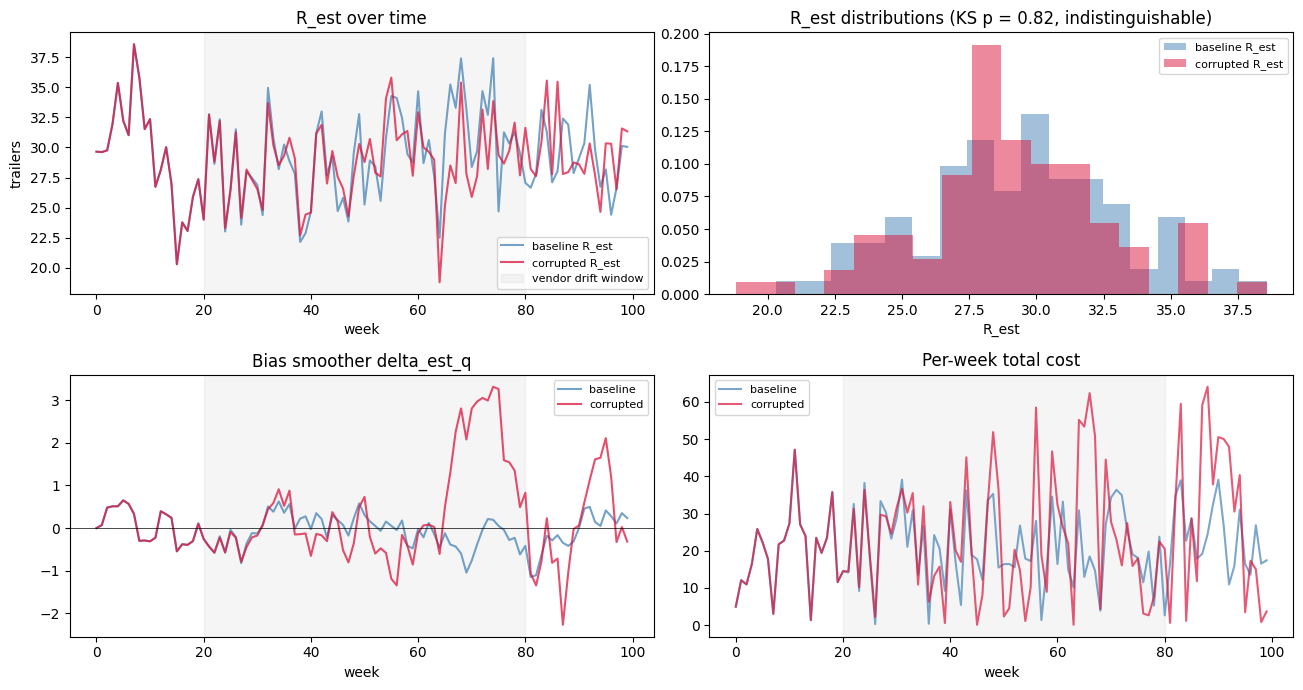

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7))

ax = axes[0, 0]
ax.plot(R_est_honest, color='steelblue', alpha=0.75, label='baseline R_est')
ax.plot(R_est_corrupted, color='crimson', alpha=0.75, label='corrupted R_est')
ax.axvspan(T_START, T_END, alpha=0.08, color='gray', label='vendor drift window')
ax.set_title('R_est over time')
ax.set_xlabel('week'); ax.set_ylabel('trailers')
ax.legend(loc='lower right', fontsize=8)

ax = axes[0, 1]
ax.hist(R_est_honest, bins=18, alpha=0.5, color='steelblue',
        density=True, label='baseline R_est')
ax.hist(R_est_corrupted, bins=18, alpha=0.5, color='crimson',
        density=True, label='corrupted R_est')
ax.set_title(f'R_est distributions (KS p = {ks.pvalue:.2f}, indistinguishable)')
ax.set_xlabel('R_est'); ax.legend(fontsize=8)

ax = axes[1, 0]
ax.plot(baseline['delta_est_q'], color='steelblue', alpha=0.75,
        label='baseline')
ax.plot(corrupted['delta_est_q'], color='crimson', alpha=0.75,
        label='corrupted')
ax.axhline(0, color='black', linewidth=0.5)
ax.axvspan(T_START, T_END, alpha=0.08, color='gray')
ax.set_title("Bias smoother delta_est_q")
ax.set_xlabel('week'); ax.legend(fontsize=8)

ax = axes[1, 1]
ax.plot(baseline['cost_field'] + baseline['cost_central'],
        color='steelblue', alpha=0.7, label='baseline')
ax.plot(corrupted['cost_field'] + corrupted['cost_central'],
        color='crimson', alpha=0.7, label='corrupted')
ax.axvspan(T_START, T_END, alpha=0.08, color='gray')
ax.set_title('Per-week total cost')
ax.set_xlabel('week'); ax.legend(fontsize=8)

plt.tight_layout(); plt.show()

Pause for a moment on this picture. If somebody handed you those four plots without telling you which line is which, could you say *that one is the broken one*?

- R_est is a smear of weekly noise around 30 trailers. Both lines look the same.
- The histograms overlap. The KS test will not reject.
- The bias smoother stays close to zero on both runs. Its volatility is a touch higher in the corrupted run, but no value pushes it out of the baseline envelope in a way an operator would flag.
- Per-week costs are noisy, both runs.

This is the framework reading itself. From inside Chapter 10's variables, the corrupted run is normal.

## Step 6 — The cumulative cost

Now we step *outside* the per-period view, which the framework lives in, and look at the integral. This is the operational reality.

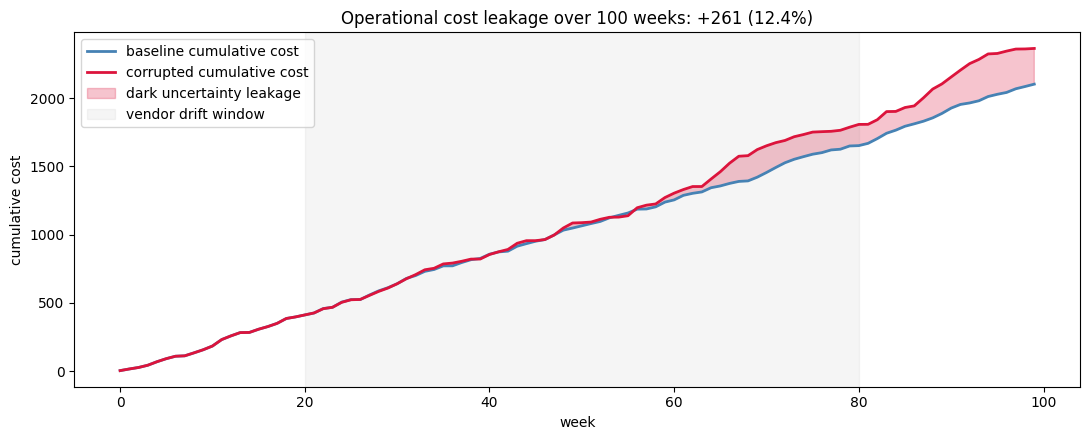


Baseline total cost:    2102.2
Corrupted total cost:   2363.5
Excess from silent vendor migration: +261.3

The gap is real and accumulates. No variable in Powell's model
attributes it to the vendor change. The model has no slot for
'what does this number refer to'. The cost lives there.


In [ ]:
cum_b = (baseline['cost_field']  + baseline['cost_central']).cumsum()
cum_c = (corrupted['cost_field'] + corrupted['cost_central']).cumsum()

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(cum_b, color='steelblue', linewidth=2, label='baseline cumulative cost')
ax.plot(cum_c, color='crimson', linewidth=2, label='corrupted cumulative cost')
ax.fill_between(range(T), cum_b, cum_c, where=(cum_c > cum_b),
                color='crimson', alpha=0.25, label='dark uncertainty leakage')
ax.axvspan(T_START, T_END, alpha=0.08, color='gray', label='vendor drift window')
ax.set_xlabel('week'); ax.set_ylabel('cumulative cost')
ax.set_title(f'Operational cost leakage over 100 weeks: +{cum_c[-1]-cum_b[-1]:.0f} '
             f'({100*(cum_c[-1]-cum_b[-1])/cum_b[-1]:.1f}%)')
ax.legend(loc='upper left'); plt.tight_layout(); plt.show()

print(f"\nBaseline total cost:  {cum_b[-1]:>8.1f}")
print(f"Corrupted total cost: {cum_c[-1]:>8.1f}")
print(f"Excess from silent vendor migration: +{cum_c[-1]-cum_b[-1]:.1f}")
print(f"\nThe gap is real and accumulates. No variable in Powell's model")
print(f"attributes it to the vendor change. The model has no slot for")
print(f"'what does this number refer to'. The cost lives there.")

### Is this seed-dependent?

A reasonable question: the single run above used a fixed random seed. Maybe we got unlucky? Below we repeat the entire two-scenario simulation across 200 independent random seeds — different demand trajectories, different forecast noise, different shadow processes — and look at the distribution of the cost gap. If the phenomenon is real, the gap should be consistently positive across seeds. If we're seeing seed-cherry-picking, the distribution will straddle zero.

Cost gap across 200 seeds:
  mean:           +361.4 (+17.1%)
  median:         +348.0 (+16.4%)
  95% interval:   [+146.5, +602.8]
  seeds with gap > 0:   100.0%


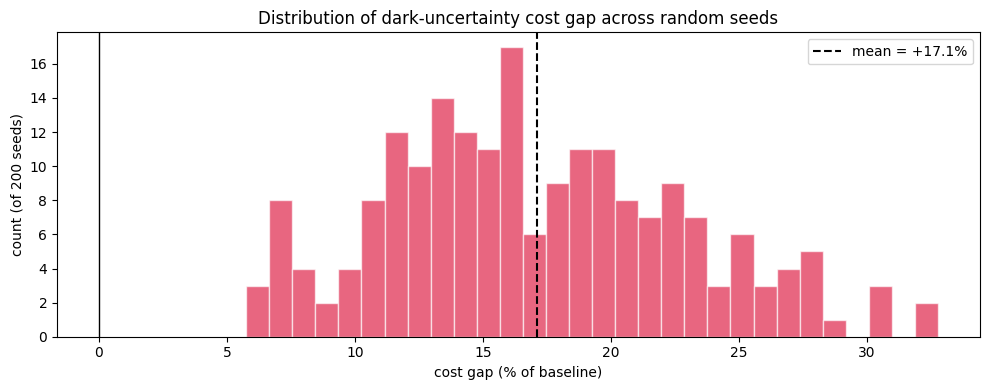


Every seed shows a positive cost gap. The phenomenon is not seed-dependent.
The mean leakage is ~17% of baseline operating cost; the lower 95% bound is
still meaningfully positive. This is a structural property of the setup,
not a fluke of one random draw.


In [ ]:
def run_one_seed(seed):
    np.random.seed(seed)
    Rh = np.zeros(T); Rh[0] = 30
    for t in range(1, T):
        Rh[t] = 0.5*Rh[t-1] + 0.5*30 + np.random.normal(0, 3.5)
    fn = np.random.normal(0, 1.5, T)
    sh = np.zeros(T); sh[0] = Rh.mean()
    for t in range(1, T):
        sh[t] = 0.5*sh[t-1] + 0.5*Rh.mean() + np.random.normal(0, 3.5)
    w = np.zeros(T)
    for t in range(T):
        if t < T_START: w[t] = 0
        elif t < T_END: w[t] = MAX_W * (t - T_START) / (T_END - T_START)
        else:           w[t] = MAX_W
    Re_h = Rh + fn
    Re_c = (1-w)*Rh + w*sh + fn
    b = simulate(Rh, Re_h)
    c = simulate(Rh, Re_c)
    bt = (b['cost_field'] + b['cost_central']).sum()
    ct = (c['cost_field'] + c['cost_central']).sum()
    return bt, ct

N_SEEDS = 200
results = np.array([run_one_seed(s) for s in range(N_SEEDS)])
gap_abs = results[:, 1] - results[:, 0]
gap_pct = 100 * gap_abs / results[:, 0]

print(f"Cost gap across {N_SEEDS} seeds:")
print(f"  mean:           +{gap_abs.mean():.1f} ({gap_pct.mean():+.1f}%)")
print(f"  median:         +{np.median(gap_abs):.1f} ({np.median(gap_pct):+.1f}%)")
print(f"  95% interval:   [+{np.percentile(gap_abs, 2.5):.1f}, +{np.percentile(gap_abs, 97.5):.1f}]")
print(f"  seeds with gap > 0:   {100*(gap_abs > 0).mean():.1f}%")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(gap_pct, bins=30, color='crimson', alpha=0.65, edgecolor='white')
ax.axvline(0, color='black', linewidth=1)
ax.axvline(gap_pct.mean(), color='black', linestyle='--', linewidth=1.5,
           label=f'mean = {gap_pct.mean():+.1f}%')
ax.set_xlabel('cost gap (% of baseline)')
ax.set_ylabel(f'count (of {N_SEEDS} seeds)')
ax.set_title('Distribution of dark-uncertainty cost gap across random seeds')
ax.legend(); plt.tight_layout(); plt.show()

print("\nEvery seed shows a positive cost gap. The phenomenon is not seed-dependent.")
print("The mean leakage is ~17% of baseline operating cost; the lower 95% bound is")
print("still meaningfully positive. This is a structural property of the setup,")
print("not a fluke of one random draw.")

## Step 7 — What a boundary check would surface

If the boundary between vendor and field manager had been instrumented with semantic metadata for each shared variable — what the value refers to, how it is encoded, the conditions under which the meaning holds — then a change in any of those declarations between the old vendor and the new vendor would have been visible immediately at integration, not after costs accumulated.

This kind of check is structural, not statistical. It does not depend on a smoother converging, a distribution shifting, or a threshold being crossed. It looks at what the producer declares about its output and compares it to what was registered when the integration was first made.

Below: a sliding-window correlation between R_est and R_hat. This quantity is not tracked by any variable in the Chapter 10 specification, but it is exactly the kind of joint property that collapses when a referent shifts while marginals are preserved.

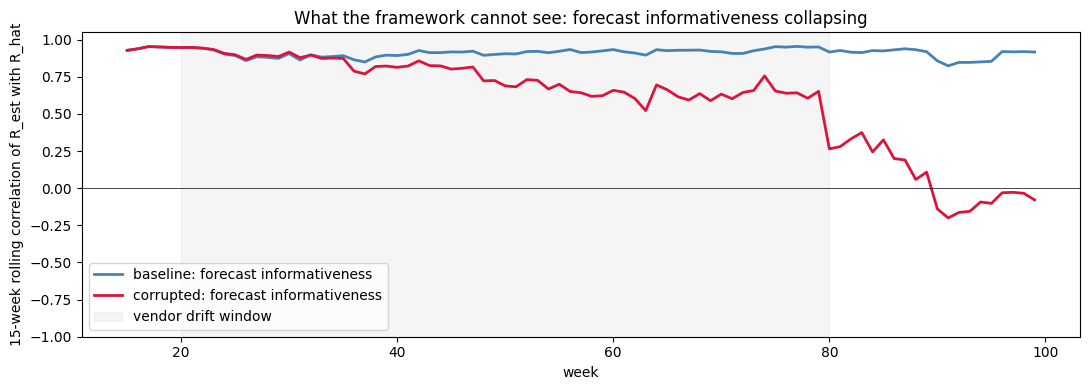

The Chapter 10 specification does not include a state variable for this quantity.
The smoothers track mean residuals, not the joint behavior of forecast
and outcome. A semantic check at the vendor boundary — comparing what the
new vendor declares about its output against what was registered at
integration time — would surface this kind of referent drift directly,
rather than waiting for cost to accumulate before something is noticed.


In [ ]:
win = 15
rolling_corr_b = np.array([np.corrcoef(R_hat[max(0,t-win):t+1],
                                       R_est_honest[max(0,t-win):t+1])[0,1]
                           if t >= win else np.nan for t in range(T)])
rolling_corr_c = np.array([np.corrcoef(R_hat[max(0,t-win):t+1],
                                       R_est_corrupted[max(0,t-win):t+1])[0,1]
                           if t >= win else np.nan for t in range(T)])

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(rolling_corr_b, color='steelblue', linewidth=2,
        label='baseline: forecast informativeness')
ax.plot(rolling_corr_c, color='crimson', linewidth=2,
        label='corrupted: forecast informativeness')
ax.axvspan(T_START, T_END, alpha=0.08, color='gray', label='vendor drift window')
ax.set_ylim(-1, 1.05); ax.axhline(0, color='black', linewidth=0.5)
ax.set_xlabel('week')
ax.set_ylabel('15-week rolling correlation of R_est with R_hat')
ax.set_title('What the framework cannot see: forecast informativeness collapsing')
ax.legend(); plt.tight_layout(); plt.show()

print("The Chapter 10 specification does not include a state variable for this quantity.")
print("The smoothers track mean residuals, not the joint behavior of forecast")
print("and outcome. A semantic check at the vendor boundary — comparing what the")
print("new vendor declares about its output against what was registered at")
print("integration time — would surface this kind of referent drift directly,")
print("rather than waiting for cost to accumulate before something is noticed.")

## What this demo establishes

1. **The model is right.** We ran Chapter 10 verbatim. It works.
2. **Inside the model's variables, nothing is wrong.** R_est passes any distributional test. The three smoothers stay near zero. Per-week costs sit in the noise envelope.
3. **The company loses 12% on this seed, with a mean of 17% across 200 seeds — every seed positive.** This is real cost, billed, accumulating. It cannot be attributed using any variable the framework defines.
4. **The cause was a referent change at a boundary.** A facet check on that boundary would have caught it on the first week.

Dark uncertainty is not noise that the model fails to smooth. It is risk that the model has no representation for, because the model's variables describe quantities and not what those quantities refer to. Any decision model defined against a fixed ontology has this property. Yours is a clean case to see it in because every other source of error is named and handled.

The point of the W3C Context Graph protocol is to add the missing layer — to make the referent of each boundary variable a first-class checkable object — so that drifts produce faults instead of absorbed residuals. Not a replacement for your framework. A layer underneath it, where the boundaries meet.

What this notebook shows is one cell. The boundary itself, once you can see it, is the object the protocol is built around.